## Top k visibility curve

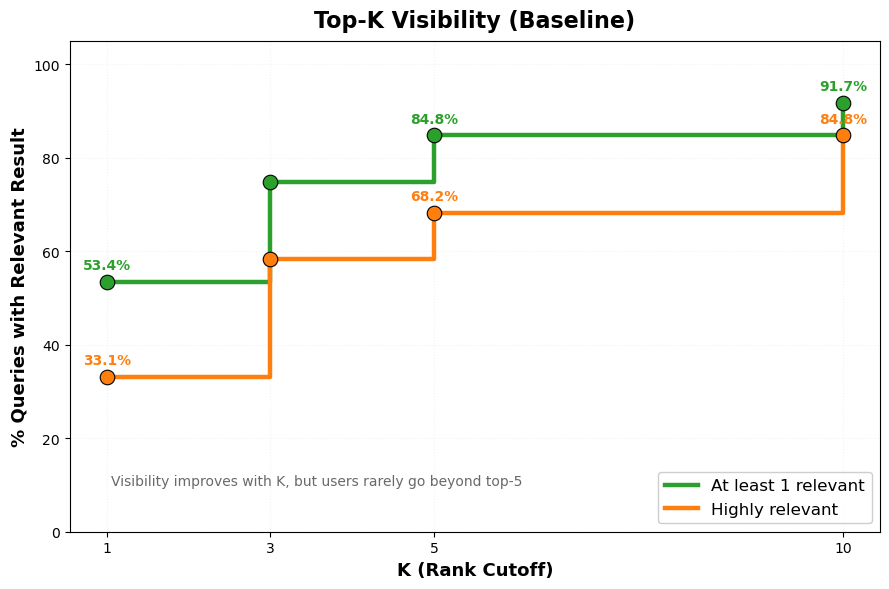

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_topk_visibility_curve.png


In [38]:
# Poster Plot: Top-K Visibility Curve
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE9_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase9_robustness'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

sens_file = PHASE9_OUTPUT / 'phase9_threshold_sensitivity.csv'
sens_df = pd.read_csv(sens_file)

# Keep MQ2007 only
if sens_df['dataset'].dtype == object:
    plot_df = sens_df[sens_df['dataset'] == '2007'].copy()
else:
    plot_df = sens_df[sens_df['dataset'] == 2007].copy()

# Visibility = 100 - Failure %
plot_df['visibility_pct'] = 100 - plot_df['pct_failures']

fig, ax = plt.subplots(figsize=(9, 6))

plot_specs = [
    (1, 'At least 1 relevant', '#2ca02c'),   # green
    (2, 'Highly relevant', '#ff7f0e')        # orange
]

for rel_thresh, label, color in plot_specs:
    sub = plot_df[plot_df['relevance_threshold'] == rel_thresh].sort_values('k')

    ax.step(
        sub['k'],
        sub['visibility_pct'],
        where='post',
        linewidth=3.2,
        label=label,
        color=color
    )

    ax.scatter(
        sub['k'],
        sub['visibility_pct'],
        s=110,
        color=color,
        edgecolors='black',
        linewidths=0.8,
        zorder=3
    )

    # Label only the most important K values to avoid clutter
    for _, row in sub.iterrows():
        if row['k'] in [1, 5, 10]:
            ax.annotate(
                f"{row['visibility_pct']:.1f}%",
                (row['k'], row['visibility_pct']),
                textcoords='offset points',
                xytext=(0, 9),
                ha='center',
                fontsize=10,
                fontweight='bold',
                color=color
            )

ax.set_xlabel('K (Rank Cutoff)', fontsize=13, fontweight='bold')
ax.set_ylabel('% Queries with Relevant Result', fontsize=13, fontweight='bold')
ax.set_title('Top-K Visibility (Baseline)', fontsize=16, fontweight='bold', pad=10)

ax.set_xticks([1, 3, 5, 10])
ax.set_ylim(0, 105)

ax.grid(alpha=0.15, linestyle=':')
ax.legend(fontsize=12, loc='lower right', framealpha=0.95)

# Optional: small note inside plot
ax.text(
    1.05,
    10,
    'Visibility improves with K, but users rarely go beyond top-5',
    fontsize=10,
    color='dimgray'
)

plt.tight_layout()

output_path = POSTER_OUTPUT / 'poster_topk_visibility_curve.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)

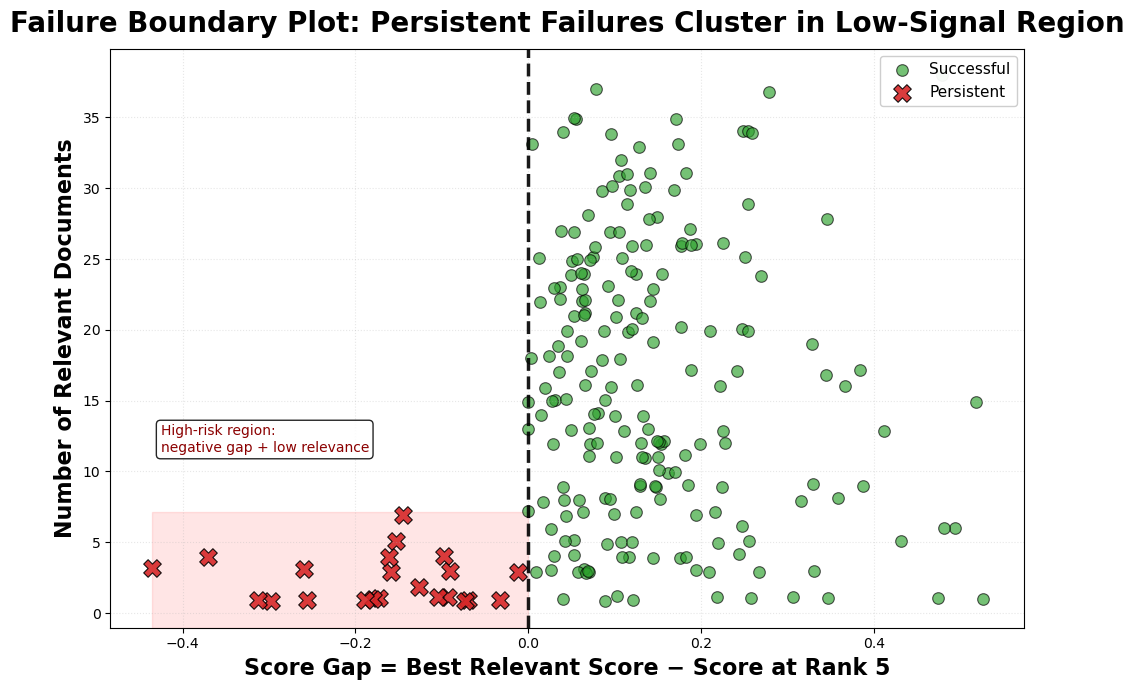

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_failure_boundary_plot.png


In [15]:
# Poster Plot: Failure Boundary Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product

PROJECT_ROOT = Path.cwd().parent
PHASE6_FOLDS_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase6_models_folds'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

FOLD = 'Fold1'
DATASET = '2007'
BASELINE_KEY = 'pointwise_raw_2007'

MODELS = ['pointwise', 'pairwise', 'lightgbm']
PIPELINES = ['raw', 'global', 'per_query']

# Load baseline query metrics and predictions
qm = pd.read_csv(PHASE6_FOLDS_OUTPUT / FOLD / f'{BASELINE_KEY}_query_metrics.csv')
pred = pd.read_csv(PHASE6_FOLDS_OUTPUT / FOLD / f'{BASELINE_KEY}_predictions.csv')

# Robust failure flag parser
def make_fail_flag(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)

    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).round().astype(int).clip(0, 1)

    return series.map(
        lambda v: 1 if str(v).strip().lower() in ['true', '1', 'yes'] else 0
    ).fillna(0).astype(int)

# Reconstruct persistent and successful query sets
evaluable_sets = {}
failure_sets = {}

for model, pipeline in product(MODELS, PIPELINES):
    key = f'{model}_{pipeline}_{DATASET}'
    qm_config = pd.read_csv(PHASE6_FOLDS_OUTPUT / FOLD / f'{key}_query_metrics.csv')

    evaluable_sets[key] = set(qm_config.loc[qm_config['num_relevant_1'] > 0, 'qid'])

    fail_flag = make_fail_flag(qm_config['Failure@5_primary'])
    fail_mask = (qm_config['num_relevant_1'] > 0) & (fail_flag == 1)

    failure_sets[key] = set(qm_config.loc[fail_mask, 'qid'])

all_evaluable = set.intersection(*evaluable_sets.values())
persistent_qids = set.intersection(*failure_sets.values())
all_failing = set.union(*failure_sets.values())
successful_qids = all_evaluable - all_failing

# Compute score_gap = best relevant score - score at rank 5
def compute_score_gap(qid):
    q_docs = pred[pred['qid'] == qid].copy()

    if len(q_docs) == 0:
        return np.nan

    q_docs = q_docs.sort_values('score', ascending=False)

    relevant = q_docs[q_docs['label'] >= 1]
    if len(relevant) == 0:
        return np.nan

    best_rel_score = float(relevant['score'].max())

    k_actual = min(5, len(q_docs))
    score_at_rank_5 = float(q_docs.iloc[k_actual - 1]['score'])

    return best_rel_score - score_at_rank_5

# Build plotting dataframe
rows = []

for qid in persistent_qids:
    row = qm[qm['qid'] == qid]
    if len(row) == 0:
        continue

    row = row.iloc[0]

    rows.append({
        'qid': qid,
        'group': 'Persistent',
        'num_relevant_1': int(row['num_relevant_1']),
        'score_gap': compute_score_gap(qid)
    })

for qid in successful_qids:
    row = qm[qm['qid'] == qid]
    if len(row) == 0:
        continue

    row = row.iloc[0]

    rows.append({
        'qid': qid,
        'group': 'Successful',
        'num_relevant_1': int(row['num_relevant_1']),
        'score_gap': compute_score_gap(qid)
    })

plot_df = pd.DataFrame(rows).dropna()

# Add slight y-jitter so integer counts do not overlap too much
rng = np.random.RandomState(36)
plot_df['num_relevant_1_jitter'] = (
    plot_df['num_relevant_1'] + rng.uniform(-0.18, 0.18, len(plot_df))
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# High-risk shaded region: negative score gap + low relevance
x_min = plot_df['score_gap'].min()
x_pos = x_min + 0.01
y_pos = plot_df['num_relevant_1'].max() * 0.30

ax.axvspan(
    x_min,
    0,
    ymin=0,
    ymax=0.20,
    alpha=0.10,
    color='red'
)

ax.text(
    x_pos,
    y_pos,
    'High-risk region:\nnegative gap + low relevance',
    fontsize=10,
    color='darkred',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.85
    )
)

# Scatter points
plot_styles = [
    ('Successful', '#2ca02c', 'o', 70),
    ('Persistent', '#d62728', 'X', 160)
]

for group, color, marker, size in plot_styles:
    sub = plot_df[plot_df['group'] == group]

    ax.scatter(
        sub['score_gap'],
        sub['num_relevant_1_jitter'],
        c=color,
        marker=marker,
        s=size,
        alpha=0.65 if group == 'Successful' else 0.9,
        edgecolors='black',
        linewidths=0.8,
        label=group
    )

# Boundary line
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2.5,
    alpha=0.9
)

# Labels and title
ax.set_xlabel(
    'Score Gap = Best Relevant Score − Score at Rank 5',
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Relevant Documents',
    fontsize=16,
    fontweight='bold'
)

ax.set_title(
    'Failure Boundary Plot: Persistent Failures Cluster in Low-Signal Region',
    fontsize=20,
    fontweight='bold',
    pad=12
)

ax.grid(alpha=0.3, linestyle=':')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()

output_path = POSTER_OUTPUT / 'poster_failure_boundary_plot.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)

In [21]:
import pandas as pd
from pathlib import Path
from itertools import product

# Paths
PROJECT_ROOT = Path.cwd().parent
PHASE6_OUTPUT = PROJECT_ROOT / "data" / "processed" / "phase6_models_folds"

# Config
DATASET = "2007"
FOLD = "Fold1"
MODELS = ["pointwise", "pairwise", "lightgbm"]
PIPELINES = ["raw", "global", "per_query"]

def make_fail_flag(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).round().astype(int).clip(0, 1)
    return series.map(lambda v: 1 if str(v).lower() in ["true", "1", "yes"] else 0).astype(int)

# Storage
query_metrics = {}
evaluable_sets = {}
failure_sets = {}

# Load all 9 model × pipeline query_metrics files
for model, pipeline in product(MODELS, PIPELINES):
    key = f"{model}_{pipeline}_{DATASET}"
    file_path = PHASE6_OUTPUT / FOLD / f"{key}_query_metrics.csv"
    
    if not file_path.exists():
        raise RuntimeError(f"Missing file: {file_path}")
    
    qm = pd.read_csv(file_path)
    
    required_cols = ["qid", "num_relevant_1", "Failure@5_primary"]
    for col in required_cols:
        if col not in qm.columns:
            raise RuntimeError(f"Missing column {col} in {file_path}")
    
    query_metrics[key] = qm
    
    # Evaluable = query has at least one relevant doc
    evaluable_sets[key] = set(qm.loc[qm["num_relevant_1"] > 0, "qid"])
    
    # Failing = evaluable AND Failure@5_primary == 1
    fail_flag = make_fail_flag(qm["Failure@5_primary"])
    fail_mask = (qm["num_relevant_1"] > 0) & (fail_flag == 1)
    failure_sets[key] = set(qm.loc[fail_mask, "qid"])

# All queries from baseline file
baseline_key = f"pointwise_raw_{DATASET}"
baseline_qm = query_metrics[baseline_key]

all_queries = set(baseline_qm["qid"])

# Evaluable queries common across all configs
evaluable_queries = set.intersection(*evaluable_sets.values())

# Failing queries = fail in at least one config
failing_queries = set.union(*failure_sets.values())

# Persistent failures = fail in all 9 configs
persistent_failures = set.intersection(*failure_sets.values())

# Summary table
summary_counts = pd.DataFrame({
    "stage": [
        "All queries",
        "Evaluable queries",
        "Failing queries",
        "Persistent failures"
    ],
    "definition": [
        "All test queries in MQ2007 Fold1 baseline file",
        "Queries with num_relevant_1 > 0",
        "Evaluable queries failing in at least one model/pipeline config",
        "Evaluable queries failing across all 9 model/pipeline configs"
    ],
    "count": [
        len(all_queries),
        len(evaluable_queries),
        len(failing_queries),
        len(persistent_failures)
    ],
    "percent_of_all_queries": [
        len(all_queries) / len(all_queries) * 100,
        len(evaluable_queries) / len(all_queries) * 100,
        len(failing_queries) / len(all_queries) * 100,
        len(persistent_failures) / len(all_queries) * 100
    ],
    "percent_of_evaluable_queries": [
        None,
        100,
        len(failing_queries) / len(evaluable_queries) * 100,
        len(persistent_failures) / len(evaluable_queries) * 100
    ]
})

display(summary_counts)

,stage,definition,count,percent_of_all_queries,percent_of_evaluable_queries
0,All queries,All test queries in MQ2007 Fold1 baseline file,336,100.000000,NaN
1,Evaluable queries,Queries with num_relevant_1 > 0,290,86.309524,100.000000
2,Failing queries,Evaluable queries failing in at least one mode...,85,25.297619,29.310345
3,Persistent failures,Evaluable queries failing across all 9 model/p...,22,6.547619,7.586207


Columns found:
['qid', 'label', 'score']
Number of candidate qids: 20
First 10 candidate qids: [8092, 8137, 8182, 8422, 8463, 8683, 8832, 9012, 9302, 9329]
Selected qids: [8092, 8137]


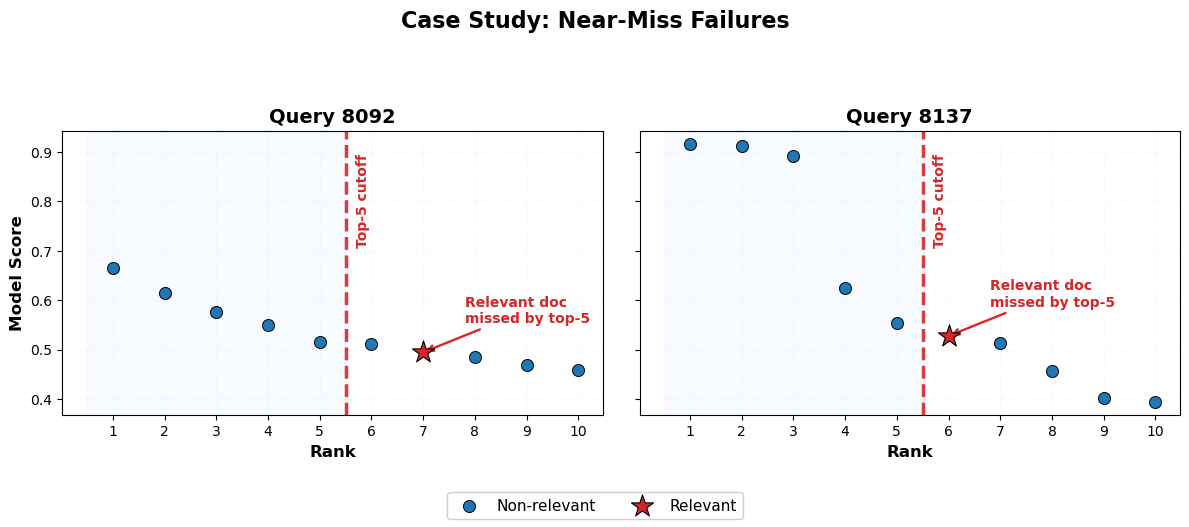

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_case_study_rankings.png


In [31]:
# Poster Panel 8: Case Study Plot from Baseline Predictions

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE6_FOLDS_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase6_models_folds'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

FOLD = 'Fold1'
BASELINE_KEY = 'pointwise_raw_2007'

pred_file = PHASE6_FOLDS_OUTPUT / FOLD / f'{BASELINE_KEY}_predictions.csv'
pred = pd.read_csv(pred_file)

print("Columns found:")
print(pred.columns.tolist())

required_cols = ['qid', 'score', 'label']
missing = [col for col in required_cols if col not in pred.columns]

if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Available columns are: {pred.columns.tolist()}"
    )

pred = pred.copy()
pred['score'] = pd.to_numeric(pred['score'])
pred['label'] = pd.to_numeric(pred['label'])

# Rank documents within each query by descending model score
pred = pred.sort_values(['qid', 'score'], ascending=[True, False])
pred['rank'] = pred.groupby('qid').cumcount() + 1

top10 = pred[pred['rank'] <= 10].copy()

# Find queries where relevant document is missed by top 5 but appears in top 10
candidate_qids = []

for qid, group in top10.groupby('qid'):
    has_relevant_top5 = ((group['label'] >= 1) & (group['rank'] <= 5)).any()
    has_relevant_6_to_10 = ((group['label'] >= 1) & (group['rank'] > 5)).any()

    if (not has_relevant_top5) and has_relevant_6_to_10:
        candidate_qids.append(qid)

print("Number of candidate qids:", len(candidate_qids))
print("First 10 candidate qids:", candidate_qids[:10])

if len(candidate_qids) < 2:
    raise ValueError(
        "Still fewer than 2 suitable examples found.\n"
        "Send me the printed candidate count and first qids."
    )

selected_qids = candidate_qids[:2]
print("Selected qids:", selected_qids)

# Plot two examples
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, qid in zip(axes, selected_qids):
    q = top10[top10['qid'] == qid].sort_values('rank').copy()

    nonrel = q[q['label'] == 0]
    rel = q[q['label'] >= 1]

    # Shade visible top-5 area
    ax.axvspan(0.5, 5.5, color='#eaf3ff', alpha=0.35)

    ax.scatter(
        nonrel['rank'],
        nonrel['score'],
        s=75,
        color='#1f77b4',
        edgecolors='black',
        linewidths=0.7,
        label='Non-relevant',
        zorder=3
    )

    ax.scatter(
        rel['rank'],
        rel['score'],
        s=280,
        color='#d62728',
        marker='*',
        edgecolors='black',
        linewidths=0.8,
        label='Relevant',
        zorder=5
    )

    ax.axvline(
        5.5,
        color='#d62728',
        linestyle='--',
        linewidth=2.5,
        alpha=0.9
    )

    ax.text(
    5.7,
    0.92,
    'Top-5 cutoff',
    transform=ax.get_xaxis_transform(),
    color='#d62728',
    fontsize=10,
    fontweight='bold',
    rotation=90,
    va='top'

    )

    rel_after_cutoff = rel[rel['rank'] > 5].sort_values('rank')

    if len(rel_after_cutoff) > 0:
        target = rel_after_cutoff.iloc[0]

        ax.annotate(
            'Relevant doc\nmissed by top-5',
            xy=(target['rank'], target['score']),
            xytext=(target['rank'] + 0.8, target['score'] + 0.06),
            arrowprops=dict(
                arrowstyle='->',
                color='#d62728',
                lw=1.7
            ),
            fontsize=10,
            color='#d62728',
            fontweight='bold'
        )

    ax.set_title(f'Query {qid}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Rank', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.grid(alpha=0.15, linestyle=':')

axes[0].set_ylabel('Model Score', fontsize=12, fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    fontsize=11,
    framealpha=0.95
)

fig.suptitle(
    'Case Study: Near-Miss Failures',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout(rect=[0, 0.10, 1, 0.94])

output_path = POSTER_OUTPUT / 'poster_case_study_rankings.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)

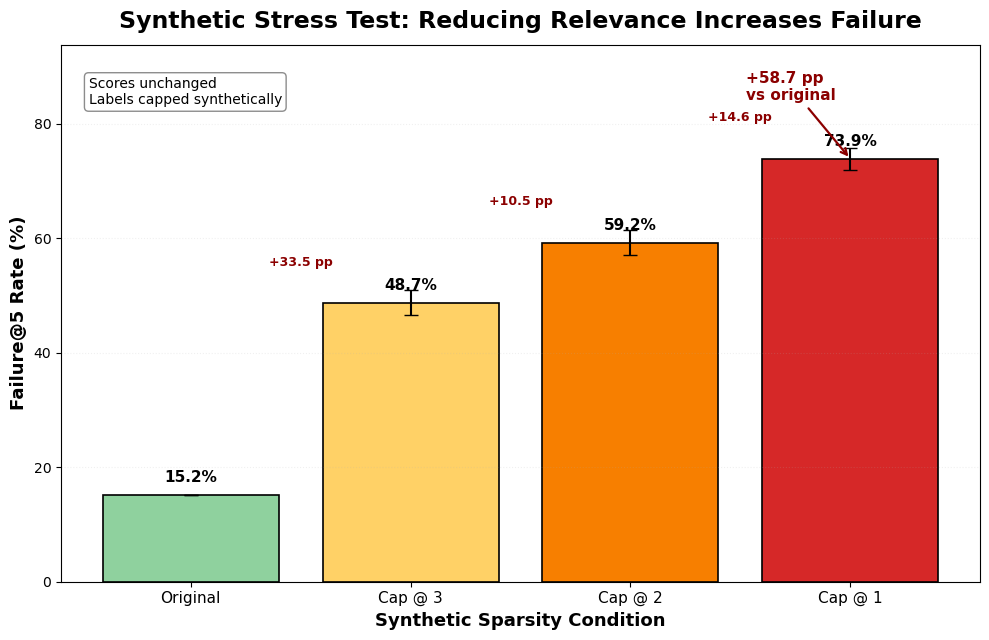

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_synthetic_stress_test.png


In [37]:
# Poster Plot 5: Synthetic Stress Test - final version with increments between bars

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE12_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase12_synthetic_stress'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_csv(PHASE12_OUTPUT / 'phase12_sparsity_stress_summary.csv')

level_order = ['original', 'cap_rel_3', 'cap_rel_2', 'cap_rel_1']
summary_df['sparsity_level'] = pd.Categorical(
    summary_df['sparsity_level'],
    categories=level_order,
    ordered=True
)

summary_df = summary_df.sort_values('sparsity_level').reset_index(drop=True)

x = np.arange(len(summary_df))
y = summary_df['mean_failure_pct'].values
yerr = summary_df['std_failure_rate'].values * 100

colors = ['#8fd19e', '#ffd166', '#f77f00', '#d62828']

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.bar(
    x,
    y,
    yerr=yerr,
    capsize=5,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# Bar value labels
for i, row in summary_df.iterrows():
    ax.annotate(
        f'{row["mean_failure_pct"]:.1f}%',
        (x[i], y[i]),
        textcoords='offset points',
        xytext=(0, 9),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Incremental gains between bars
for i in range(1, len(y)):
    diff = y[i] - y[i - 1]

    x_mid = (x[i - 1] + x[i]) / 2
    y_mid = max(y[i - 1], y[i]) + 6

    ax.text(
        x_mid,
        y_mid,
        f'+{diff:.1f} pp',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='darkred'
    )

# Final increase annotation only
orig = summary_df.iloc[0]['mean_failure_pct']
last = summary_df.iloc[-1]['mean_failure_pct']
delta = last - orig

ax.annotate(
    f'+{delta:.1f} pp\nvs original',
    xy=(x[-1], y[-1]),
    xytext=(-75, 42),
    textcoords='offset points',
    fontsize=11,
    fontweight='bold',
    color='darkred',
    arrowprops=dict(
        arrowstyle='->',
        lw=1.6,
        color='darkred'
    )
)

# Small method note
ax.text(
    0.03,
    0.94,
    'Scores unchanged\nLabels capped synthetically',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

ax.set_xticks(x)
ax.set_xticklabels(
    ['Original', 'Cap @ 3', 'Cap @ 2', 'Cap @ 1'],
    fontsize=11
)

ax.set_xlabel('Synthetic Sparsity Condition', fontsize=13, fontweight='bold')
ax.set_ylabel('Failure@5 Rate (%)', fontsize=13, fontweight='bold')

ax.set_title(
    'Synthetic Stress Test: Reducing Relevance Increases Failure',
    fontsize=17,
    fontweight='bold',
    pad=12
)

ax.grid(axis='y', alpha=0.18, linestyle=':')
ax.set_ylim(0, max(y + yerr) + 18)

plt.tight_layout()

output_path = POSTER_OUTPUT / 'poster_synthetic_stress_test.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
plt.show()

print("Saved:", output_path)